# Quick start: forecasting page views with Prophet

Can a model learn nearly a decade of changing interest in one person—and forecast the next year—with only a few lines of code?

In this lesson, you will:

- prepare a time series in Prophet's required format;
- fit a [Prophet](https://facebook.github.io/prophet/) forecasting model;
- generate one year of daily predictions; and
- interpret the forecast and its uncertainty interval.

## Prophet's input format

Prophet expects a [pandas](https://pandas.pydata.org/docs/) DataFrame with two columns:

- `ds` (**datestamp**) contains each observation's date or timestamp. Use a format pandas understands, preferably `YYYY-MM-DD` or `YYYY-MM-DD HH:MM:SS`.
- `y` contains the numeric quantity to forecast.

In [1]:
import pandas as pd

# Construct a sample DataFrame in Prophet's required format.
# 'ds' is a list of dates as strings; 'y' is a list of numeric values to forecast.
example_data = {
    'ds': [
        '2024-01-01',
        '2024-01-02',
        '2024-01-03',
        '2024-01-04',
        '2024-01-05'
    ],
    'y': [
        10.5,
        12.3,
        11.9,
        13.2,
        12.7
    ]
}

prophet_df = pd.DataFrame(example_data)
prophet_df.head()

,ds,y
0,2024-01-01,10.5
1,2024-01-02,12.3
2,2024-01-03,11.9
3,2024-01-04,13.2
4,2024-01-05,12.7


## The data: daily interest in Peyton Manning

We will forecast daily views of [Peyton Manning's Wikipedia page](https://en.wikipedia.org/wiki/Peyton_Manning). This series is a useful teaching example because public interest changes over time, follows weekly and yearly patterns, and spikes around events such as playoff and Super Bowl appearances.

The [`Wikipediatrend`](https://cran.r-project.org/package=wikipediatrend) R package was used to collect the original view counts. The [CSV supplied by Prophet](https://github.com/facebook/prophet/blob/main/examples/example_wp_log_peyton_manning.csv) has already transformed those counts: `y` is the **natural logarithm of daily page views**, not the raw number of views.

### Why use a logarithm?

Daily page views are non-negative and highly skewed: an important event can produce a spike many times larger than an ordinary day. Taking the logarithm:

1. compresses extreme spikes so they do not dominate the fitted model;
2. makes the variability more consistent across low- and high-traffic periods; and
3. turns multiplicative changes on the original scale into approximately additive changes, which matches Prophet's default additive structure.

The model therefore forecasts on the log scale. To interpret a prediction as approximate page views, transform it back with `exp(yhat)`. Apply the same transformation to `yhat_lower` and `yhat_upper` when interpreting the interval.

First we’ll fetch the data:

In [2]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv"
)

# Prophet needs dates as datetime objects, not strings.
df["ds"] = pd.to_datetime(df["ds"])

df

,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572
...,...,...
2900,2016-01-16,7.817223
2901,2016-01-17,9.273878
2902,2016-01-18,10.333775
2903,2016-01-19,9.125871


## How Prophet models a time series

Prophet uses an API similar to scikit-learn: create a `Prophet` instance, call `fit` with the historical data, and call `predict` with the dates to forecast.

In [3]:
from prophet import Prophet

We fit the model by instantiating a new `Prophet` object. Any settings to the forecasting procedure are passed into the constructor. Then you call its `fit` method and pass in the historical dataframe. Fitting should take 1-5 seconds.

In [4]:
m = Prophet()
m.fit(df)

12:13:30 - cmdstanpy - INFO - Chain [1] start processing
12:13:30 - cmdstanpy - INFO - Chain [1] done processing


Predictions are then made on a dataframe with a column `ds` containing the dates for which a prediction is to be made. You can get a suitable dataframe that extends into the future a specified number of days using the helper method `Prophet.make_future_dataframe`. By default it will also include the dates from the history, so we will see the model fit as well.

In [5]:
future = m.make_future_dataframe(periods=365)
future.tail()

,ds
3265,2017-01-15
3266,2017-01-16
3267,2017-01-17
3268,2017-01-18
3269,2017-01-19


The `predict` method will assign each row in `future` a predicted value which it names `yhat`. If you pass in historical dates, it will provide an in-sample fit. The `forecast` object here is a new dataframe that includes a column `yhat` with the forecast, as well as columns for components and uncertainty intervals.

In [6]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
3265,2017-01-15,8.210119,7.445410,8.972230
3266,2017-01-16,8.535144,7.787094,9.243821
3267,2017-01-17,8.322571,7.624731,9.045614
3268,2017-01-18,8.155201,7.397238,8.889702
3269,2017-01-19,8.167158,7.430251,8.871708


## Interpret the forecast plot

Pass the forecast DataFrame to `Prophet.plot` to compare the observations with the fitted values and future predictions.

In the plot below:

- **Black points** are the observed daily log page views in the historical data.
- The **dark blue line** is `yhat`, Prophet's fitted value for historical dates and its forecast for future dates.
- The **light blue band** spans `yhat_lower` to `yhat_upper`, the default uncertainty interval.
- The forecast period begins after the final black point and continues for the 365 days added to `future`.

The smooth line captures the underlying trend and repeating seasonal patterns rather than every short-lived spike. Large points above the line correspond to bursts of attention that the default model cannot explain with trend and seasonality alone. The vertical axis remains on the natural-log scale, so equal vertical changes represent equal **ratios**, not equal numbers of page views. For example, increasing by 1 on this axis means multiplying the expected page views by approximately `e ≈ 2.72`.

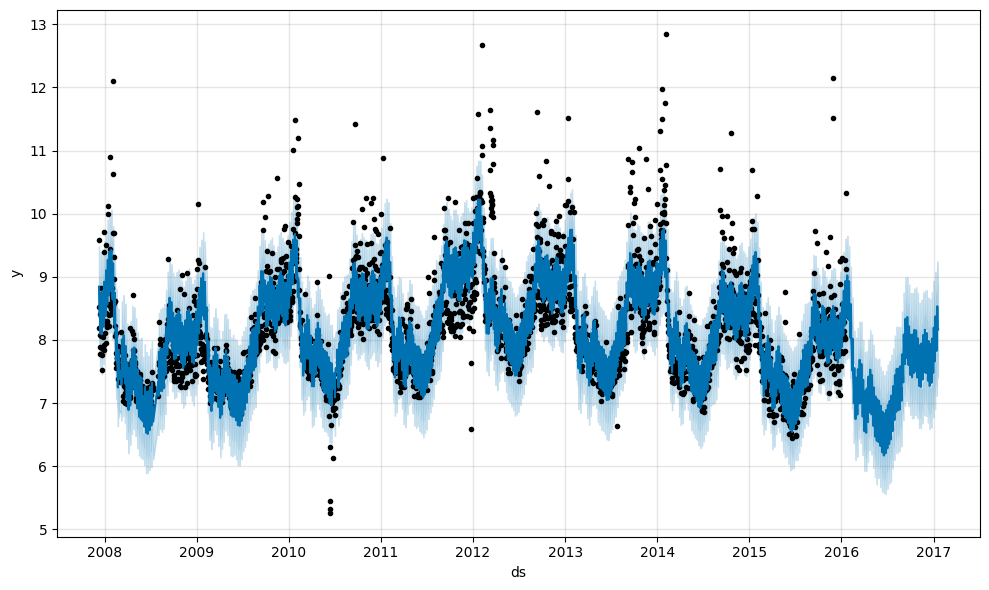

In [7]:
fig1 = m.plot(forecast)

## Forecast on the original scale

The previous plot uses log page views. To read the same forecast in daily page views, undo the log with `np.exp()` on:

- the historical `y` values that Prophet plots as black points; and
- `yhat`, `yhat_lower`, and `yhat_upper` in the forecast DataFrame.

Then pass that transformed forecast to Prophet's own `plot` method. The chart below zooms to the last year of history plus the one-year forecast, and hides a few extreme spike days so typical traffic is easier to see. The model still trains on every row.

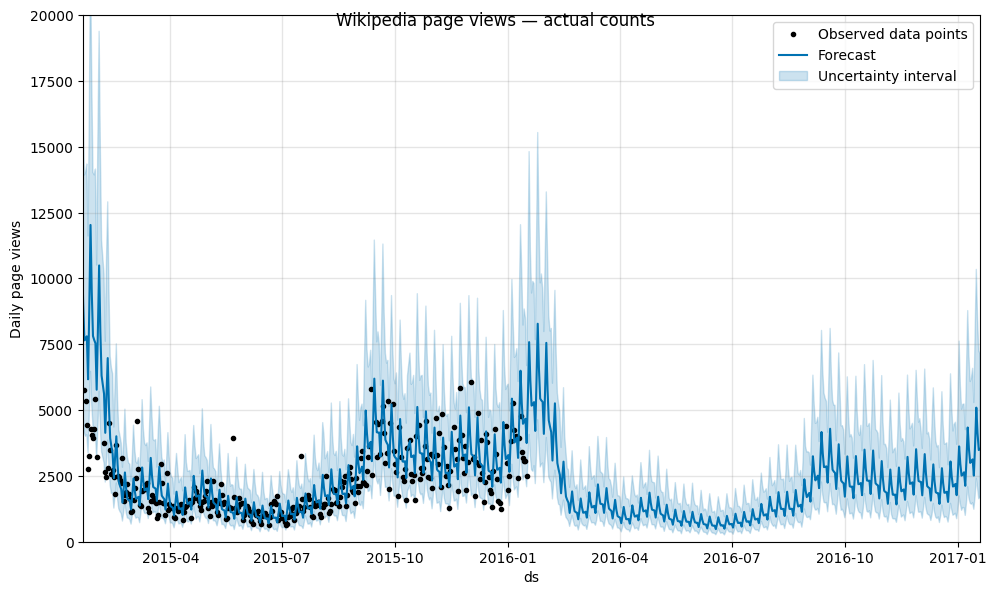

In [16]:
import numpy as np

history_end = m.history["ds"].max()
plot_start = history_end - pd.DateOffset(years=1)

# Undo the log transform so Prophet plots daily page views.
fcst_pageviews = forecast.assign(
    yhat=lambda frame: np.exp(frame["yhat"]),
    yhat_lower=lambda frame: np.exp(frame["yhat_lower"]),
    yhat_upper=lambda frame: np.exp(frame["yhat_upper"]),
)

plot_history = m.history.assign(y=lambda frame: np.exp(frame["y"])).copy()
plot_history = plot_history.loc[plot_history["ds"] >= plot_start]

# Hide extreme spike days so the chart is easier to read.
q1, q3 = plot_history["y"].quantile([0.25, 0.75])
upper_fence = q3 + 1.5 * (q3 - q1)
plot_history = plot_history.loc[plot_history["y"] <= upper_fence]

# Prophet's plot() reads m.history; swap in filtered page-view history temporarily.
saved_history = m.history
m.history = plot_history
try:
    fig2 = m.plot(
        fcst_pageviews,
        ylabel="Daily page views",
        include_legend=True,
    )
    fig2.axes[0].set_xlim(plot_start, fcst_pageviews["ds"].max())
    fig2.axes[0].set_ylim(0, 20_000)
    fig2.suptitle("Wikipedia page views — actual counts")
finally:
    m.history = saved_history